# Validation of the window with integral constraints

In [1]:
import logging

import os

import numpy as np
import matplotlib.pyplot as plt

import lsstypes

logger = logging.getLogger('FIT PNG')

plt.style.use('ec_style.mplstyle')   

# remove warning on my mac -> deactivate on NERSC.
os.environ['OMPI_MCA_btl'] = 'self,tcp'  # deactivate shmem
# disable jax warning:
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
logging.getLogger("jax._src.distributed").setLevel(logging.ERROR)
# Remove warning from jax
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [2]:
def propose_fiducial(kmin=1e-3, kmax=8e-2, region='GCcomb'):
    propose_fiducial = {}

    propose_fiducial['LRG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.4, 1.1), 'region': region, 
                               'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}

    propose_fiducial['QSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 3.5), 'region': region, 
                               'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
      
    return propose_fiducial


def load_data(data_dir, mocks_dir, tracer, fiducial=propose_fiducial(), window_extra='RIC+AMR',
              kpivot=[1e-2, 2e-2], nrebin=[2,2], weight_type_mocks=None):
    """ 
    """
    import lsstypes 

    from tools import read_data, rebin_data

    short_tracer = tracer.replace('_zcmb', '')
    short_tracer = short_tracer.replace('notqso', '')

    if weight_type_mocks is None: weight_type_mocks = 'default-noimsys-fkp-oqe_reshuffle' if window_extra == '' else 'default-fkp-oqe'
    logger.info(f"Reading data for tracer {tracer} with weight type {weight_type_mocks} and window_extra={window_extra}.")

    kwargs = fiducial[short_tracer]

    pk, window, cov, mock = read_data(data_dir=data_dir, mocks_dir=mocks_dir, tracer=tracer, window_extra=window_extra,
                                        weight_type_mocks=weight_type_mocks, **kwargs)
    pk, window, cov, mock = rebin_data(pk, window, cov, mock, tracer=tracer, kpivot=kpivot, nrebin=nrebin, **kwargs)
    try: 
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} and {pk.get(2).k.shape[0]} data points.')
    except KeyError:
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} data points.')

    zeff = {}
    zeff[0] = window.observable.get(0).attrs['zeff']
    try: 
        zeff[2] = window.observable.get(2).attrs['zeff']
    except KeyError:
        pass

    return pk, window, cov, zeff, mock

In [3]:
# root = '/global/cfs/cdirs/desi/science/cai/desi-clustering/'
root = '/Users/edmond/Work/data/desi-clustering/' 

# Where the data are:
data_dir =  root + 'dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded'
# Where the mocks are:
mocks_dir = root + 'dr2/summary_statistics/local_png/base/'


pk, window, _, zeff, mocks = load_data(data_dir, mocks_dir, 'QSO', propose_fiducial(), window_extra='RIC+AMR')
zeffs = {'QSOxQSO': zeff}

window_ini = lsstypes.read(data_dir + '/window_mesh2_spectrum_poles_QSO_z0.8-3.5_SGC_weight-default-fkp-oqe_RIC+AMR.h5')
window_ini = window_ini.at.observable.match(pk)

+------------------------------------+--------+---------+-------+
| chi2 / (42 - 4) = 9.90 / 38 = 0.26 | varied | bestfit | error |
+------------------------------------+--------+---------+-------+
|              fnl_loc               |  True  |  -0.3   |  3.6  |
|            QSO_ell0.sn0            |  True  | -0.069  | 0.046 |
|            QSO_ell0.b1             |  True  |  3.066  | 0.044 |
|          QSO_ell0.sigmas           |  True  |  5.17   | 0.28  |
|            QSO_ell2.b1             |  True  |   2.9   |       |
|          QSO_ell2.sigmas           |  True  |   5.2   |       |
+------------------------------------+--------+---------+-------+


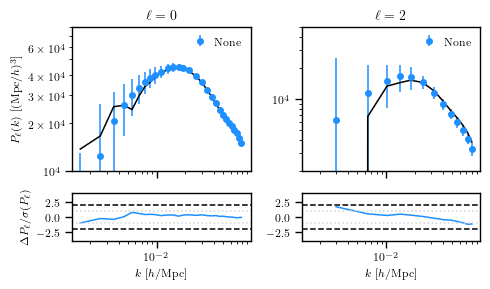

In [5]:
from tools import get_observable_and_likelihood, run_profiler, plot_observables

obs, lik = get_observable_and_likelihood(lsstypes.mean(mocks), window_ini, mocks, 'QSO', zeffs, engine='camb', fix_fnl=False, nickname='QSO') 
prof = run_profiler(lik)
print(prof.profiles.to_stats(tablefmt="pretty"))
plot_observables({'QSO': obs}, figsize=(5,3), show=True, fn_output='fig/validation_window_0.png')

For now the theory is looking very weird ... Let's check what is going on!


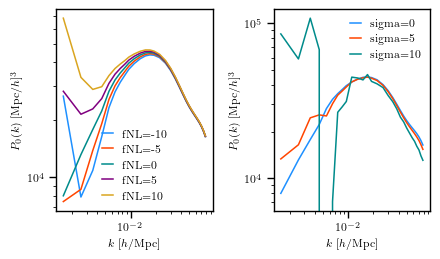

Ok ... something happens when sigma increases... Looks like a small effect propagated into large scales --> This could be a window problem!


In [42]:
print("For now the theory is looking very weird ... Let's check what is going on!")

plt.figure(figsize=(4.5, 2.7))

test = obs[0].copy()

plt.subplot(121)
for fnl in [-10, -5, 0, 5, 10]:
    test(fnl_loc=fnl, **{'QSO_ell0.b1': 3.083, 'QSO_ell0.sn0': -0.065, 'QSO_ell0.sigmas': 0})
    plt.loglog(test.data.get(0).k, test.flattheory, label=f'fNL={fnl}')
plt.legend()
plt.xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
plt.ylabel(r'$P_0(k)$ [Mpc/$h$]$^3$')

plt.subplot(122)
for sigma in [0, 5, 10]:
    test(fnl_loc=0, **{'QSO_ell0.b1': 3.083, 'QSO_ell0.sn0': -0.065, 'QSO_ell0.sigmas': sigma})
    plt.loglog(test.data.get(0).k, test.flattheory, label=f'sigma={sigma}')
plt.legend()
plt.xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
plt.ylabel(r'$P_0(k)$ [Mpc/$h$]$^3$')
plt.tight_layout()
plt.savefig('fig/validation_window_1.png', dpi=400)
plt.show()

print('Ok ... something happens when sigma increases... Looks like a small effect propagated into large scales --> This could be a window problem!')

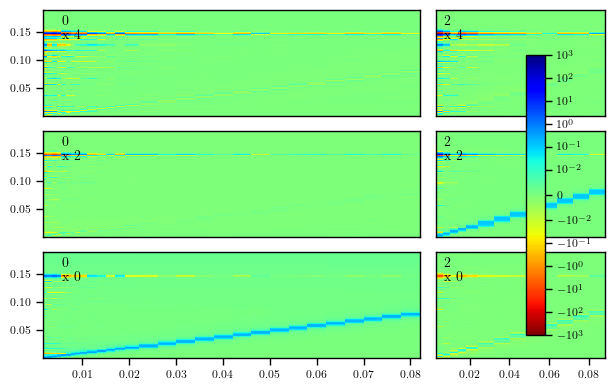

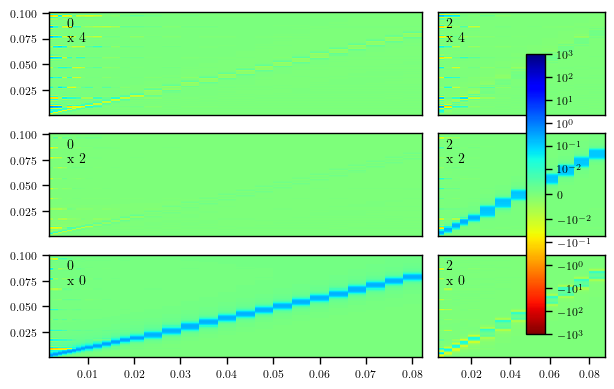

In [43]:
import matplotlib.colors as mcolors
norm_sym = mcolors.SymLogNorm(linthresh=1e-2, linscale=1.0, vmin=-1e3, vmax=1e3)

import warnings
warnings.filterwarnings('ignore', message='.*tight_layout.*')

_ = window_ini.plot(norm=norm_sym, figsize=(5, 4))
plt.savefig('fig/validation_window_2.png', dpi=400)
plt.show()

window_test = window_ini.at.theory.select(k=(1e-4,0.1))

_ = window_test.plot(norm=norm_sym, figsize=(5, 4))
plt.savefig('fig/validation_window_3.png', dpi=400)
plt.show()

*From conversation with Domitille and Arnaud.*

There are "two issues" on this plot:
* The large artifact/spike: it appears right around that k_Nyquist value; in the FM windows before rebinning, the last bin contains modes above k_Nyquist — hence the failure. The key is that the theoretical k_max (input theory) exceeds the Nyquist wavenumber of the observation, which is problematic.
    * Plan: add something in desi-clustering to enforce a theory k_max matched to the Nyquist of the mesh used for the window — this should fully fix the large spike issue.
* The small artifacts: these are rebinning artifacts, expected to not add physically meaningful features in the power spectrum.
    * Plan: change the rebinning kernel to be more visually uniform on the matrix --> but no significant change to the spectrum is expected.

+------------------------------------+--------+---------+-------+
| chi2 / (42 - 4) = 1.22 / 38 = 0.03 | varied | bestfit | error |
+------------------------------------+--------+---------+-------+
|              fnl_loc               |  True  |  -0.1   |  4.1  |
|            QSO_ell0.sn0            |  True  |  0.013  | 0.053 |
|            QSO_ell0.b1             |  True  |  3.073  | 0.046 |
|          QSO_ell0.sigmas           |  True  |  6.06   | 0.40  |
|            QSO_ell2.b1             |  True  |   2.9   |       |
|          QSO_ell2.sigmas           |  True  |   6.1   |       |
+------------------------------------+--------+---------+-------+


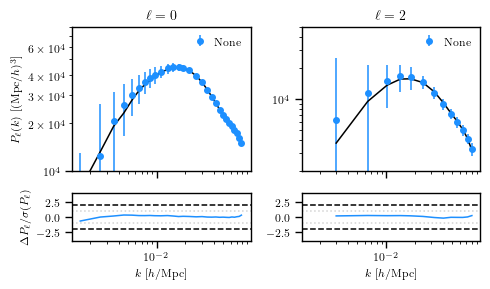

In [44]:
from tools import get_observable_and_likelihood, run_profiler, plot_observables

obs, lik = get_observable_and_likelihood(lsstypes.mean(mocks), window_test, mocks, 'QSO', zeffs, engine='camb', fix_fnl=False, nickname='QSO') 
prof = run_profiler(lik)
print(prof.profiles.to_stats(tablefmt="pretty"))
plot_observables({'QSO': obs}, figsize=(5,3), show=True, fn_output='fig/validation_window_4.png')

#